In [5]:
import pandas as pd
df = pd.read_csv("raw_data.csv.gz")  # pandas auto-detects gzip

C:\Users\DELL\AppData\Local\Temp\ipykernel_15924\534664467.py:2: DtypeWarning: Columns (0: number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("raw_data.csv.gz")  # pandas auto-detects gzip


In [ ]:
"""
RIDEQUEST - PHASE 1: Data Cleaning, Feature Extraction & EDA
================================================================
Run order: 1st
Input : raw_data.csv  (columns: ts, number, pick_lat, pick_lng, drop_lat, drop_lng)
Output: phase1_cleaned_features.csv   -> feeds into Phase 2
        phase1_*.png                  -> EDA visualizations

NOTE ON SCHEMA ASSUMPTIONS
---------------------------
The original prompt assumed a schema with `request_id`, `driver_id`, and a
`status` enum ('completed', 'cancelled_driver', 'cancelled_rider',
'no_driver_found'). Our actual source data does NOT contain those fields —
every row is simply a raw ride request with pickup/drop coordinates and a
timestamp. That means:
  - We cannot separate "true demand" (cancellations + no-driver-found +
    completed) from "fulfilled demand" the way the prompt describes, because
    there is no status field. Every row here IS treated as a demand signal
    (a request was made), which is the closest honest equivalent.
  - There's no `driver_id`, so no supply-side analysis is possible in Phase 1.
  - If you later get access to a dataset WITH a status field, re-introduce
    the `include_as_demand = status.isin(['completed','cancelled_driver',
    'cancelled_rider','no_driver_found'])` filter noted inline below.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: no matplotlib.use("Agg") here — this lets plt.show() pop up
# interactive windows when you run this locally in VS Code / a terminal
# with a display. Each plot is still saved to a PNG as before.

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
RAW_PATH = "raw_data.csv.gz"                 # update to your local path
OUTPUT_CSV = "phase1_cleaned_features.csv"

# City bounding box (Bangalore / Karnataka, matches source data's ops area)
CITY_LAT_MIN, CITY_LAT_MAX = 11.5945587, 18.4767308
CITY_LNG_MIN, CITY_LNG_MAX = 74.0543908, 78.588083


# ------------------------------------------------------------------
# 1. LOAD + SANITY-CHECK CLEANING
# ------------------------------------------------------------------
def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # --- Handle missing timestamps / coordinates ---
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    required_cols = ["ts", "pick_lat", "pick_lng", "drop_lat", "drop_lng"]
    before = len(df)
    df = df.dropna(subset=required_cols)
    print(f"[clean] dropped {before - len(df):,} rows with missing timestamp/coords")

    # --- Remove duplicate request rows ---
    # (no request_id in this dataset, so we treat an exact full-row duplicate
    #  as the equivalent of a duplicate request_id)
    before = len(df)
    df = df.drop_duplicates()
    print(f"[clean] dropped {before - len(df):,} exact duplicate rows")

    # --- Spatial outlier filter: keep only points inside city bounding box ---
    pick_ok = df["pick_lat"].between(CITY_LAT_MIN, CITY_LAT_MAX) & \
              df["pick_lng"].between(CITY_LNG_MIN, CITY_LNG_MAX)
    drop_ok = df["drop_lat"].between(CITY_LAT_MIN, CITY_LAT_MAX) & \
              df["drop_lng"].between(CITY_LNG_MIN, CITY_LNG_MAX)
    before = len(df)
    df = df[pick_ok & drop_ok]
    print(f"[clean] dropped {before - len(df):,} rows outside city bounding box")

    # --- Zero-distance / erroneous trips ---
    def haversine_km(lat1, lng1, lat2, lng2):
        R = 6371.0088
        lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
        dlat, dlng = lat2 - lat1, lng2 - lng1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2) ** 2
        return R * 2 * np.arcsin(np.sqrt(a))

    if "trip_distance_km" not in df.columns:
        df["trip_distance_km"] = haversine_km(
            df["pick_lat"].values, df["pick_lng"].values,
            df["drop_lat"].values, df["drop_lng"].values
        )

    before = len(df)
    df = df[df["trip_distance_km"] >= 0.05]  # drop <50m "zero distance" trips
    print(f"[clean] dropped {before - len(df):,} zero/near-zero distance trips")

    return df.reset_index(drop=True)


# ------------------------------------------------------------------
# 2. TIME FEATURE EXTRACTION
# ------------------------------------------------------------------
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df["hour_of_day"] = df["ts"].dt.hour
    df["day_of_week"] = df["ts"].dt.dayofweek        # 0=Monday
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["month"] = df["ts"].dt.month

    # is_holiday: no holiday calendar is available in this dataset.
    # Wire in a real calendar (e.g. `holidays` package for India) if you
    # have one; defaulting to 0 rather than fabricating holiday dates.
    df["is_holiday"] = 0

    return df


# ------------------------------------------------------------------
# 3. TIME-WINDOW RESAMPLING (city-level demand curve)
# ------------------------------------------------------------------
def resample_demand(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """Aggregate raw requests into uniform time buckets (e.g. '15min', '1H')."""
    s = df.set_index("ts").resample(freq).size()
    return s.rename("request_count").reset_index()


# ------------------------------------------------------------------
# 4. VISUALIZATIONS
# ------------------------------------------------------------------
def plot_hour_day_heatmap(df: pd.DataFrame, out_path: str):
    pivot = df.groupby(["day_of_week", "hour_of_day"]).size().unstack(fill_value=0)
    day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, cmap="YlOrRd", yticklabels=day_labels)
    plt.title("Ride Demand Heatmap: Hour of Day vs Day of Week")
    plt.xlabel("Hour of Day")
    plt.ylabel("Day of Week")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


def plot_hourly_trend(hourly_demand: pd.DataFrame, out_path: str):
    plt.figure(figsize=(16, 5))
    plt.plot(hourly_demand["ts"], hourly_demand["request_count"], linewidth=0.8)
    plt.title("Hourly Ride Request Volume Over Time")
    plt.xlabel("Date")
    plt.ylabel("Requests per hour")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


def plot_spatial_scatter(df: pd.DataFrame, out_path: str, sample_n: int = 50_000):
    sample = df.sample(min(sample_n, len(df)), random_state=42)
    is_peak = sample["hour_of_day"].isin([8, 9, 18, 19, 20]).map({True: "Peak", False: "Off-peak"})
    plt.figure(figsize=(9, 9))
    sns.scatterplot(
        x=sample["pick_lng"], y=sample["pick_lat"],
        hue=is_peak, s=4, alpha=0.4, palette={"Peak": "red", "Off-peak": "steelblue"}
    )
    plt.title("Pickup Locations Colored by Peak vs Off-Peak Hour")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------
if __name__ == "__main__":
    df = load_and_clean(RAW_PATH)
    df = add_time_features(df)

    print("\nFinal cleaned + featured shape:", df.shape)

    # Resampled demand curves (city-wide) at two granularities
    demand_15min = resample_demand(df, "15min")
    demand_1hour = resample_demand(df, "1h")

    # Visualizations
    plot_hour_day_heatmap(df, "phase1_heatmap_hour_vs_day.png")
    plot_hourly_trend(demand_1hour, "phase1_hourly_trend.png")
    plot_spatial_scatter(df, "phase1_spatial_peak_scatter.png")

    # Save feature-enriched cleaned data for Phase 2
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved -> {OUTPUT_CSV}")

C:\Users\DELL\AppData\Local\Temp\ipykernel_15924\2604755911.py:50: DtypeWarning: Columns (0: number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


[clean] dropped 0 rows with missing timestamp/coords
[clean] dropped 65,698 exact duplicate rows
[clean] dropped 67,485 rows outside city bounding box
[clean] dropped 20,529 zero/near-zero distance trips

Final cleaned + featured shape: (8227844, 12)


C:\Users\DELL\AppData\Local\Temp\ipykernel_15924\2604755911.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[viz] saved phase1_heatmap_hour_vs_day.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_15924\2604755911.py:147: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[viz] saved phase1_hourly_trend.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_15924\2604755911.py:164: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[viz] saved phase1_spatial_peak_scatter.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_4980\3028024702.py:204: DtypeWarning: Columns (0: number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_PATH, parse_dates=["ts"])


Loaded Phase 1 output: (5191437, 12)

Searching for optimal K...
  k= 4 | inertia=120 | silhouette=0.4046
  k= 6 | inertia=65 | silhouette=0.4354
  k= 8 | inertia=45 | silhouette=0.3666
  k=10 | inertia=33 | silhouette=0.3851
  k=12 | inertia=25 | silhouette=0.3967
  k=14 | inertia=20 | silhouette=0.4194
  k=16 | inertia=18 | silhouette=0.4180
  k=18 | inertia=16 | silhouette=0.3968
  k=20 | inertia=14 | silhouette=0.3896


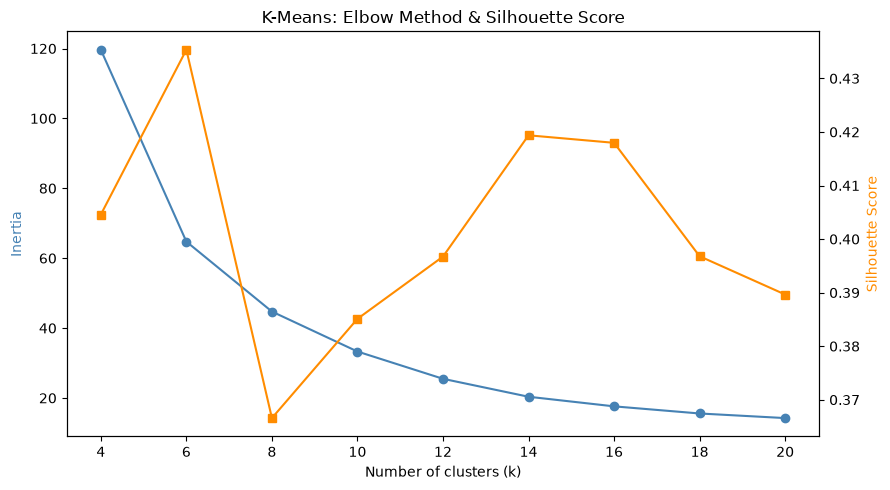

[viz] saved phase2_elbow_silhouette.png

Selected K = 6 (highest silhouette score)


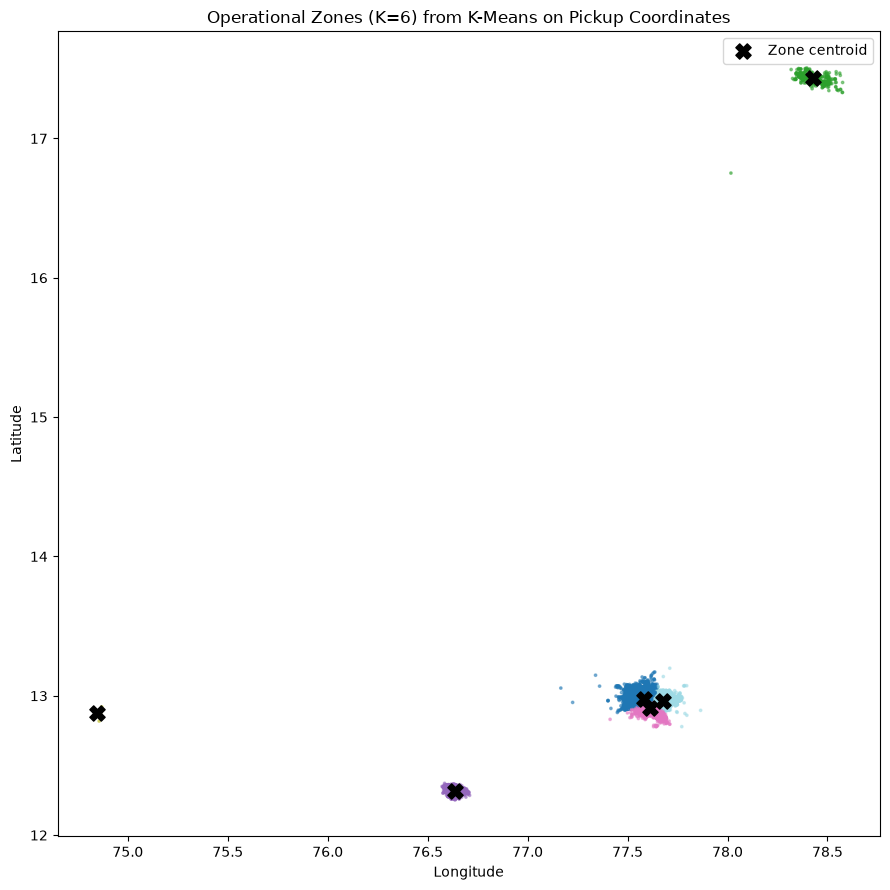

[viz] saved phase2_zone_map.png
[agg] zone x time table shape: (180834, 3) (6 zones x 30139 time windows)

Final zone-timeseries feature table shape: (180834, 17)
Saved -> phase2_zone_timeseries.csv


In [1]:
"""
RIDEQUEST - PHASE 2: Spatial Clustering & Demand Feature Engineering
========================================================================
Run order: 2nd (after Phase 1)
Input : phase1_cleaned_features.csv
Output: phase2_zone_timeseries.csv   -> feeds into Phase 3
        phase2_elbow_silhouette.png
        phase2_zone_map.png

WHY K-MEANS HERE (VS. UBER H3)
--------------------------------
Uber H3 (hexagonal hierarchical indexing) is generally preferred in
production ride-sharing systems because:
  1. It's deterministic and stateless — the zone a coordinate belongs to
     is computed instantly from a formula, with no model to retrain as new
     data arrives. K-Means zones can silently drift/need re-fitting as the
     city's demand geography changes.
  2. Hex cells are uniform in size and tile with no gaps/overlaps, so
     boundary effects (a request "on the edge" of a cluster) are more
     predictable and easier to reason about operationally.
  3. H3 has built-in multi-resolution support (zoom in/out on zone size)
     without re-running a clustering algorithm.

K-Means is used here because:
  - It's what the project brief explicitly asks for, and it's simpler to
    reason about pedagogically (you can see *why* two nearby points end up
    in different zones by inspecting the centroids).
  - It naturally concentrates smaller zones in high-density areas and
    larger zones in sparse areas, which can better match operational
    driver density than uniform hex tiles for a first-pass model.
  - It's a reasonable stepping stone before adopting H3 in a "production
    hardening" follow-up (mentioned in the Phase 4 write-up).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# NOTE: no matplotlib.use("Agg") here — this lets plt.show() pop up
# interactive windows when you run this locally in VS Code / a terminal
# with a display. Each plot is still saved to a PNG as before.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
INPUT_PATH = "phase1_cleaned_features.csv"
OUTPUT_PATH = "phase2_zone_timeseries.csv"

TIME_FREQ = "15min"          # aggregation granularity for the zone x time table
KMEANS_FIT_SAMPLE = 300_000  # fit K-Means on a sample, then predict on full data (scales to millions of rows)
K_CANDIDATES = range(4, 21, 2)  # candidate K values to test for elbow/silhouette


# ------------------------------------------------------------------
# 1. FIND OPTIMAL K (Elbow Method + Silhouette Score)
# ------------------------------------------------------------------
def find_optimal_k(coords: np.ndarray, k_candidates, sample_for_silhouette=20_000):
    inertias, sil_scores = [], []
    rng = np.random.default_rng(42)

    for k in k_candidates:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(coords)
        inertias.append(km.inertia_)

        # Silhouette is O(n^2)-ish, so score on a subsample
        idx = rng.choice(len(coords), size=min(sample_for_silhouette, len(coords)), replace=False)
        sil = silhouette_score(coords[idx], labels[idx])
        sil_scores.append(sil)
        print(f"  k={k:>2} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f}")

    return list(k_candidates), inertias, sil_scores


def plot_elbow_silhouette(ks, inertias, sil_scores, out_path):
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(ks, inertias, "o-", color="steelblue", label="Inertia (Elbow)")
    ax1.set_xlabel("Number of clusters (k)")
    ax1.set_ylabel("Inertia", color="steelblue")

    ax2 = ax1.twinx()
    ax2.plot(ks, sil_scores, "s-", color="darkorange", label="Silhouette Score")
    ax2.set_ylabel("Silhouette Score", color="darkorange")

    plt.title("K-Means: Elbow Method & Silhouette Score")
    fig.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


# ------------------------------------------------------------------
# 2. FIT FINAL K-MEANS AND ASSIGN ZONE_ID TO EVERY ROW
# ------------------------------------------------------------------
def assign_zones(df: pd.DataFrame, k: int, fit_sample: int) -> pd.DataFrame:
    coords = df[["pick_lat", "pick_lng"]].values

    # Fit on a sample for speed, then predict (assign) on the full dataset.
    # This is standard practice for large-scale spatial clustering.
    sample_idx = np.random.default_rng(42).choice(len(coords), size=min(fit_sample, len(coords)), replace=False)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords[sample_idx])

    df["zone_id"] = km.predict(coords)
    return df, km


def plot_zone_map(df: pd.DataFrame, km: KMeans, out_path: str, sample_n=100_000):
    sample = df.sample(min(sample_n, len(df)), random_state=42)
    plt.figure(figsize=(9, 9))
    scatter = plt.scatter(sample["pick_lng"], sample["pick_lat"], c=sample["zone_id"],
                           cmap="tab20", s=3, alpha=0.5)
    centers = km.cluster_centers_
    plt.scatter(centers[:, 1], centers[:, 0], c="black", marker="X", s=120, label="Zone centroid")
    plt.title(f"Operational Zones (K={km.n_clusters}) from K-Means on Pickup Coordinates")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


# ------------------------------------------------------------------
# 3. ZONE x TIME AGGREGATION, ZERO-FILLED
# ------------------------------------------------------------------
def build_zone_timeseries(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    df["time_window"] = df["ts"].dt.floor(freq)

    counts = df.groupby(["zone_id", "time_window"]).size().rename("demand_count").reset_index()

    # Build the full cartesian product of (all zones) x (all time windows)
    # so zones with 0 requests in a given window are explicit zero rows,
    # not missing rows. This matters a lot for lag/rolling features.
    all_zones = df["zone_id"].unique()
    full_range = pd.date_range(df["time_window"].min(), df["time_window"].max(), freq=freq)

    full_index = pd.MultiIndex.from_product([all_zones, full_range], names=["zone_id", "time_window"])
    zone_ts = counts.set_index(["zone_id", "time_window"]).reindex(full_index, fill_value=0)
    zone_ts = zone_ts.reset_index().sort_values(["zone_id", "time_window"]).reset_index(drop=True)

    print(f"[agg] zone x time table shape: {zone_ts.shape} "
          f"({len(all_zones)} zones x {len(full_range)} time windows)")
    return zone_ts


# ------------------------------------------------------------------
# 4. LAG FEATURES + ROLLING STATS + TARGETS (per zone)
# ------------------------------------------------------------------
def add_lag_and_rolling_features(zone_ts: pd.DataFrame, freq_minutes: int) -> pd.DataFrame:
    zone_ts = zone_ts.sort_values(["zone_id", "time_window"]).reset_index(drop=True)
    g = zone_ts.groupby("zone_id")["demand_count"]

    # --- Lag features, expressed as "N steps back" given the aggregation freq ---
    lag_spec_minutes = {
        "lag_15min": 15,
        "lag_30min": 30,
        "lag_1hour": 60,
        "lag_24hour": 60 * 24,
        "lag_7day": 60 * 24 * 7,
    }
    for name, minutes in lag_spec_minutes.items():
        steps = max(1, minutes // freq_minutes)
        zone_ts[name] = g.shift(steps)

    # --- Rolling window stats (computed on already-shifted lag_15min to avoid leakage) ---
    roll_base = g.shift(1)  # never let rolling stats see the current row's own value
    steps_1h = max(1, 60 // freq_minutes)
    steps_3h = max(1, 180 // freq_minutes)

    zone_ts["rolling_mean_1h"] = roll_base.groupby(zone_ts["zone_id"]).transform(
        lambda s: s.rolling(steps_1h, min_periods=1).mean()
    )
    zone_ts["rolling_std_1h"] = roll_base.groupby(zone_ts["zone_id"]).transform(
        lambda s: s.rolling(steps_1h, min_periods=1).std()
    )
    zone_ts["rolling_mean_3h"] = roll_base.groupby(zone_ts["zone_id"]).transform(
        lambda s: s.rolling(steps_3h, min_periods=1).mean()
    )
    zone_ts["rolling_std_3h"] = roll_base.groupby(zone_ts["zone_id"]).transform(
        lambda s: s.rolling(steps_3h, min_periods=1).std()
    )

    # --- Time features on the window itself ---
    zone_ts["hour_of_day"] = zone_ts["time_window"].dt.hour
    zone_ts["day_of_week"] = zone_ts["time_window"].dt.dayofweek
    zone_ts["is_weekend"] = zone_ts["day_of_week"].isin([5, 6]).astype(int)

    # --- Target variables: future demand ---
    steps_15min = max(1, 15 // freq_minutes)
    zone_ts["demand_next_15min"] = g.shift(-steps_15min)
    zone_ts["demand_next_1hour"] = zone_ts.groupby("zone_id")["demand_count"] \
        .transform(lambda s: s.rolling(steps_1h, min_periods=1).sum().shift(-steps_1h))

    return zone_ts


# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------
if __name__ == "__main__":
    df = pd.read_csv(INPUT_PATH, parse_dates=["ts"])
    print("Loaded Phase 1 output:", df.shape)

    coords = df[["pick_lat", "pick_lng"]].values
    fit_idx = np.random.default_rng(42).choice(len(coords), size=min(50_000, len(coords)), replace=False)

    print("\nSearching for optimal K...")
    ks, inertias, sil_scores = find_optimal_k(coords[fit_idx], K_CANDIDATES)
    plot_elbow_silhouette(ks, inertias, sil_scores, "phase2_elbow_silhouette.png")

    # Pick the K with the best silhouette score among candidates as the default.
    # Inspect phase2_elbow_silhouette.png yourself and override K_FINAL if the
    # elbow suggests a more operationally sensible number of zones.
    K_FINAL = ks[int(np.argmax(sil_scores))]
    print(f"\nSelected K = {K_FINAL} (highest silhouette score)")

    df, km = assign_zones(df, k=K_FINAL, fit_sample=KMEANS_FIT_SAMPLE)
    plot_zone_map(df, km, "phase2_zone_map.png")

    zone_ts = build_zone_timeseries(df, freq=TIME_FREQ)

    freq_minutes = 15 if TIME_FREQ == "15min" else 60
    zone_ts = add_lag_and_rolling_features(zone_ts, freq_minutes)

    print("\nFinal zone-timeseries feature table shape:", zone_ts.shape)
    zone_ts.to_csv(OUTPUT_PATH, index=False)
    print(f"Saved -> {OUTPUT_PATH}")

In [1]:
import lightgbm
print(lightgbm.__version__)

4.7.0


[prep] dropped 4,038 rows with NaN lag/target values -> 176,796 rows remain

Benchmarking on target = 'demand_next_15min' with 13 features, 5-fold TimeSeriesSplit CV

[cv] fold 1/5 done (train=29,466, test=29,466)
[cv] fold 2/5 done (train=58,932, test=29,466)
[cv] fold 3/5 done (train=88,398, test=29,466)
[cv] fold 4/5 done (train=117,864, test=29,466)
[cv] fold 5/5 done (train=147,330, test=29,466)

=== MODEL COMPARISON (mean across CV folds) ===
                    rmse_mean  rmse_std  mae_mean  mae_std     mape_mean  \
model                                                                      
LightGBM               37.948    12.619    10.903    3.855  2.239201e+07   
Ridge Regression       38.373    12.081    12.493    4.381  7.535647e+07   
XGBoost                39.225    13.973    11.022    4.005  2.116903e+07   
Naive Lag Baseline     42.021    11.996    13.213    4.523  1.617394e+07   

                    r2_mean  underpred_penalty_mean  
model                               

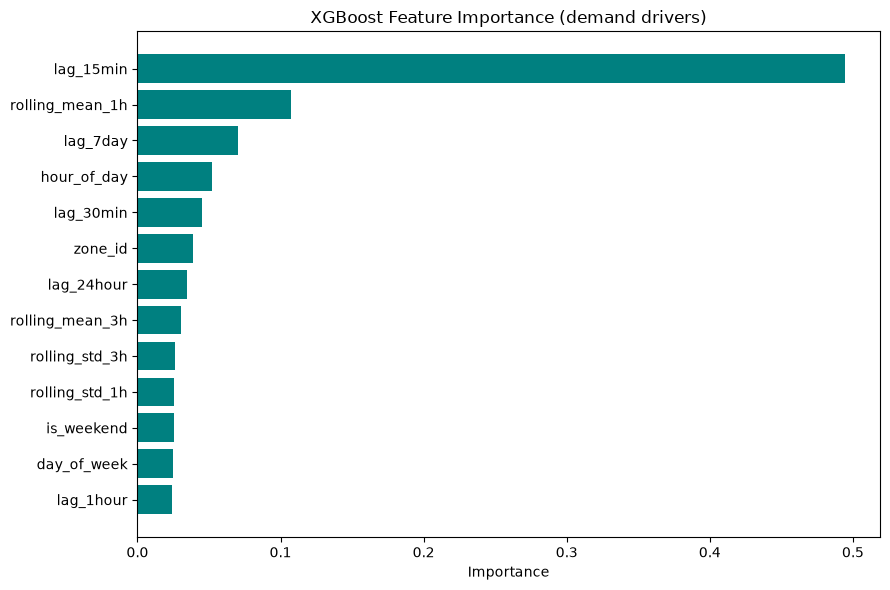

[viz] saved phase3_feature_importance.png


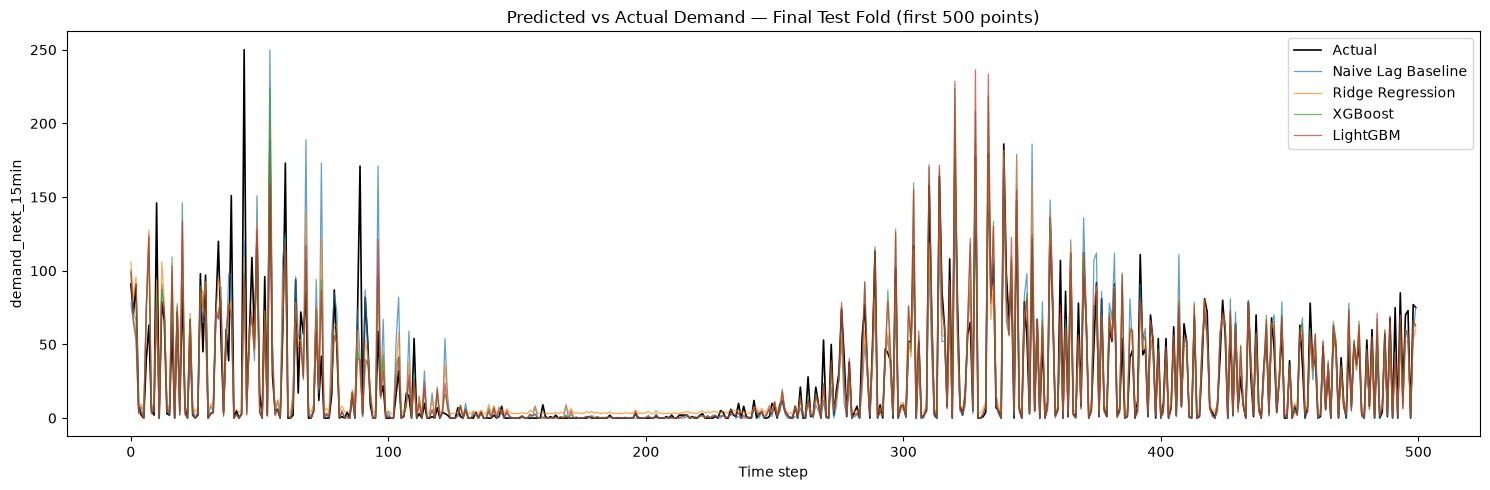

[viz] saved phase3_predictions_vs_actual.png

Best model by RMSE: LightGBM


In [2]:
"""
RIDEQUEST - PHASE 3: Model Benchmarking & Evaluation
========================================================================
Run order: 3rd (after Phase 2)
Input : phase2_zone_timeseries.csv
Output: phase3_model_comparison.csv
        phase3_feature_importance.png
        phase3_predictions_vs_actual.png

NOTE ON SCOPE
-------------
Prophet/Auto-ARIMA are mentioned in the original brief as a time-series
benchmark. They are intentionally NOT included in the automated run below:
they model ONE series at a time (per zone), so benchmarking them properly
means fitting 6 separate models (one per zone) with their own tuning, which
is a different workflow shape than the tabular panel models below. A
`fit_prophet_per_zone()` stub is included at the bottom so you can extend
this yourself per zone if you want that comparison — it's left out of the
main loop to keep this script runnable end-to-end in one pass.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# NOTE: no matplotlib.use("Agg") here — this lets plt.show() pop up
# interactive windows when you run this locally in VS Code / a terminal
# with a display. Each plot is still saved to a PNG as before.
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
INPUT_PATH = "phase2_zone_timeseries.csv"
TARGET = "demand_next_15min"   # switch to "demand_next_1hour" to benchmark that target instead

FEATURE_COLS = [
    "lag_15min", "lag_30min", "lag_1hour", "lag_24hour", "lag_7day",
    "rolling_mean_1h", "rolling_std_1h", "rolling_mean_3h", "rolling_std_3h",
    "hour_of_day", "day_of_week", "is_weekend", "zone_id",
]

N_SPLITS = 5
UNDER_PREDICTION_PENALTY_WEIGHT = 2.0  # under-forecast errors weighted 2x over-forecast


# ------------------------------------------------------------------
# CUSTOM METRIC: Supply Under-Prediction Penalty
# ------------------------------------------------------------------
def supply_underprediction_penalty(y_true, y_pred, under_weight=UNDER_PREDICTION_PENALTY_WEIGHT):
    """
    Weighted MAE that penalizes under-forecasting more than over-forecasting.
    Business rationale: predicting TOO FEW rides means understaffed zones and
    lost revenue from unmet demand; predicting too many just means idle
    driver time, which is cheaper than lost trips.
    """
    error = y_true - y_pred
    weights = np.where(error > 0, under_weight, 1.0)  # error>0 means we under-predicted
    return np.mean(weights * np.abs(error))


def mape(y_true, y_pred, epsilon=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100


# ------------------------------------------------------------------
# LOAD + PREP
# ------------------------------------------------------------------
def load_data(path: str):
    df = pd.read_csv(path, parse_dates=["time_window"])
    df = df.sort_values("time_window").reset_index(drop=True)

    # Drop rows with NaNs from lag/rolling/target creation at series edges
    model_cols = FEATURE_COLS + [TARGET]
    before = len(df)
    df = df.dropna(subset=model_cols).reset_index(drop=True)
    print(f"[prep] dropped {before - len(df):,} rows with NaN lag/target values -> {len(df):,} rows remain")

    X = df[FEATURE_COLS]
    y = df[TARGET]
    return df, X, y


# ------------------------------------------------------------------
# MODEL SUITE
# ------------------------------------------------------------------
def naive_lag_baseline(X):
    """Predicts next demand = the most recent observed lag (lag_15min)."""
    return X["lag_15min"].values


def train_ridge(X_train, y_train, X_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train_s, y_train)
    return model.predict(X_test_s), model


def train_xgboost(X_train, y_train, X_test):
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        objective="reg:squarederror", n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return model.predict(X_test), model


def train_lightgbm(X_train, y_train, X_test):
    model = lgb.LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1,
    )
    model.fit(X_train, y_train)
    return model.predict(X_test), model


# ------------------------------------------------------------------
# TIME-SERIES CROSS VALIDATION BENCHMARK
# ------------------------------------------------------------------
def run_benchmark(X: pd.DataFrame, y: pd.Series, n_splits: int = N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []
    last_fold_predictions = {}   # keep last fold's preds for plotting/SHAP
    last_fold_models = {}

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        preds = {
            "Naive Lag Baseline": naive_lag_baseline(X_test),
        }
        ridge_pred, ridge_model = train_ridge(X_train, y_train, X_test)
        preds["Ridge Regression"] = ridge_pred

        xgb_pred, xgb_model = train_xgboost(X_train, y_train, X_test)
        preds["XGBoost"] = xgb_pred

        lgb_pred, lgb_model = train_lightgbm(X_train, y_train, X_test)
        preds["LightGBM"] = lgb_pred

        for model_name, y_pred in preds.items():
            y_pred = np.clip(y_pred, 0, None)  # demand can't be negative
            results.append({
                "fold": fold,
                "model": model_name,
                "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
                "mae": mean_absolute_error(y_test, y_pred),
                "mape": mape(y_test.values, y_pred),
                "r2": r2_score(y_test, y_pred),
                "underpred_penalty": supply_underprediction_penalty(y_test.values, y_pred),
            })

        if fold == n_splits:  # keep the last (largest, most recent) fold for downstream plots
            last_fold_predictions = {**preds, "y_test": y_test, "X_test": X_test}
            last_fold_models = {"xgboost": xgb_model, "lightgbm": lgb_model}

        print(f"[cv] fold {fold}/{n_splits} done "
              f"(train={len(train_idx):,}, test={len(test_idx):,})")

    return pd.DataFrame(results), last_fold_predictions, last_fold_models


# ------------------------------------------------------------------
# VISUALIZATIONS
# ------------------------------------------------------------------
def plot_feature_importance(model, feature_names, out_path, model_name="XGBoost"):
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color="teal")
    plt.title(f"{model_name} Feature Importance (demand drivers)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


def plot_predictions_vs_actual(last_fold, out_path, n_points=500):
    y_test = last_fold["y_test"].values[:n_points]
    plt.figure(figsize=(15, 5))
    plt.plot(y_test, label="Actual", linewidth=1.2, color="black")
    for name in ["Naive Lag Baseline", "Ridge Regression", "XGBoost", "LightGBM"]:
        plt.plot(np.clip(last_fold[name][:n_points], 0, None), label=name, alpha=0.7, linewidth=0.9)
    plt.title("Predicted vs Actual Demand — Final Test Fold (first 500 points)")
    plt.xlabel("Time step")
    plt.ylabel(TARGET)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[viz] saved {out_path}")


# ------------------------------------------------------------------
# OPTIONAL: Prophet-per-zone stub (not run automatically — see note above)
# ------------------------------------------------------------------
def fit_prophet_per_zone(df: pd.DataFrame, zone_id: int):
    """
    Example of how you'd benchmark Prophet for ONE zone at a time.
    Requires: pip install prophet
    """
    from prophet import Prophet
    zone_df = df[df["zone_id"] == zone_id][["time_window", "demand_count"]].rename(
        columns={"time_window": "ds", "demand_count": "y"}
    )
    model = Prophet()
    model.fit(zone_df)
    future = model.make_future_dataframe(periods=96, freq="15min")  # next 24h
    forecast = model.predict(future)
    return forecast


# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------
if __name__ == "__main__":
    df, X, y = load_data(INPUT_PATH)

    print(f"\nBenchmarking on target = '{TARGET}' with {len(FEATURE_COLS)} features, "
          f"{N_SPLITS}-fold TimeSeriesSplit CV\n")

    results_df, last_fold, last_models = run_benchmark(X, y, N_SPLITS)

    # Aggregate CV results: mean +/- std per model, across folds
    summary = results_df.groupby("model").agg(
        rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"), mae_std=("mae", "std"),
        mape_mean=("mape", "mean"),
        r2_mean=("r2", "mean"),
        underpred_penalty_mean=("underpred_penalty", "mean"),
    ).sort_values("rmse_mean")

    print("\n=== MODEL COMPARISON (mean across CV folds) ===")
    print(summary.round(3))

    results_df.to_csv("phase3_model_comparison_by_fold.csv", index=False)
    summary.to_csv("phase3_model_comparison_summary.csv")
    print("\nSaved -> phase3_model_comparison_by_fold.csv, phase3_model_comparison_summary.csv")

    # Feature importance from the final-fold XGBoost model
    plot_feature_importance(last_models["xgboost"], FEATURE_COLS, "phase3_feature_importance.png")

    # Predicted vs actual on the final (most recent) fold
    plot_predictions_vs_actual(last_fold, "phase3_predictions_vs_actual.png")

    best_model = summary["rmse_mean"].idxmin()
    print(f"\nBest model by RMSE: {best_model}")